In [8]:
#@title Parse and Convert Solar Data Table
import pandas as pd
import io
import re # Regular expression library

def parse_solar_data_table(table_string):
    """
    Parses the provided multi-line string table into a Pandas DataFrame.

    Args:
        table_string (str): A multi-line string containing the solar data table.

    Returns:
        pd.DataFrame: A DataFrame with station names as index and columns for
                      Latitude, Longitude, Altitude, and monthly averages,
                      or None if parsing fails.
    """
    # Use StringIO to treat the string like a file
    data_io = io.StringIO(table_string)

    # --- Data Extraction using Regular Expressions ---
    # This is often more robust for tables with inconsistent spacing
    # than relying solely on fixed-width or simple delimiters.

    # Regex pattern explanation:
    # ^\s*                      # Start of line, optional whitespace
    # ([\w\s-]+?)              # Group 1: Station Name (letters, numbers, whitespace, hyphen, non-greedy)
    # \s+                       # Required whitespace separator
    # ([-+]?\d+\.?\d*)          # Group 2: Latitude (optional sign, digits, optional decimal)
    # \s+                       # Required whitespace
    # ([-+]?\d+\.?\d*)          # Group 3: Longitude
    # \s+                       # Required whitespace
    # ([\d.]+)                 # Group 4: Altitude (digits, decimal)
    # (\s+([-+]?\d+\.?\d*)){12} # Groups 5-16: Repeated 12 times - whitespace + monthly value
    # \s+                       # Required whitespace
    # ([-+]?\d+\.?\d*)          # Last Group (17 for Av column): Average value
    # \s*$                      # Optional whitespace, end of line

    # Simplified pattern focusing on capturing essential parts and handling variable spacing
    # We will extract the row first and then parse the numbers carefully
    pattern = re.compile(r"^\s*([\w\s.-]+?)\s+(-?\d+\.\d+)\s+(-?\d+\.\d+)\s+([\d.]+)\s+(.*)$")
    # Explanation:
    # ^\s*                  : Start, whitespace
    # ([\w\s.-]+?)         : Group 1: Station Name (allows '.', '-', letters, space, numbers - non-greedy)
    # \s+                   : Space
    # (-?\d+\.\d+)         : Group 2: Latitude
    # \s+                   : Space
    # (-?\d+\.\d+)         : Group 3: Longitude
    # \s+                   : Space
    # ([\d.]+)             : Group 4: Altitude (digits and '.')
    # \s+                   : Space
    # (.*)$                 : Group 5: Rest of the line (contains monthly values and avg)

    data = []
    column_names = ["Location", "Latitude", "Longitude", "Altitude",
                    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Avg"]

    lines = data_io.readlines()
    # Skip header line(s) - Adjust if header is multi-line
    header_line_count = 1 # Assuming one header line
    data_lines = lines[header_line_count:]

    for i, line in enumerate(data_lines):
        line = line.strip()
        if not line: # Skip empty lines
            continue

        match = pattern.match(line)
        if match:
            name, lat, lon, alt, rest_of_line = match.groups()
            name = name.strip() # Clean up station name whitespace

            # Now, parse the numbers from the rest_of_line using simple split
            try:
                # Split the remaining part by whitespace and convert to float
                monthly_values_str = rest_of_line.split()
                # Ensure we have exactly 13 number strings (12 months + Avg)
                if len(monthly_values_str) == 13:
                     monthly_values = [float(v) for v in monthly_values_str]
                     data.append([name, float(lat), float(lon), float(alt)] + monthly_values)
                else:
                     print(f"Warning: Line {i+header_line_count+1} '{name}' - Could not parse 13 numeric values from '{rest_of_line}'. Found {len(monthly_values_str)} values. Skipping line.")
                     print(f"   Split values: {monthly_values_str}")


            except ValueError as e:
                print(f"Warning: Line {i+header_line_count+1} '{name}' - Could not convert value to float in '{rest_of_line}'. Error: {e}. Skipping line.")
            except Exception as e:
                print(f"Warning: Unexpected error parsing values for line {i+header_line_count+1} '{name}'. Error: {e}. Skipping line.")

        else:
            # Try a simpler split as fallback, might work for well-aligned lines
            parts = line.split()
            # Check if we have enough parts (Name can be multiple words)
            # Minimum parts: 1 name word + 3 coords + 12 months + 1 avg = 17
            if len(parts) >= 17:
                 try:
                     # Assume name is everything up to the latitude
                     num_value_cols = 16 # Lat, Lon, Alt, 12 months, Avg
                     name_parts = parts[:-num_value_cols]
                     value_parts = parts[-num_value_cols:]

                     name = " ".join(name_parts).strip()
                     lat = float(value_parts[0])
                     lon = float(value_parts[1])
                     alt = float(value_parts[2])
                     monthly_values = [float(v) for v in value_parts[3:]] # 12 months + avg
                     data.append([name, lat, lon, alt] + monthly_values)
                 except ValueError:
                      print(f"Warning: Line {i+header_line_count+1} - Fallback split failed to convert value to float. Skipping line.")
                 except Exception as e:
                      print(f"Warning: Unexpected error during fallback parsing for line {i+header_line_count+1}. Error: {e}. Skipping line.")
            else:
                 print(f"Warning: Line {i+header_line_count+1} - Did not match pattern and not enough parts ({len(parts)}) for fallback split. Skipping line: '{line[:50]}...'")


    if not data:
        print("Error: No data successfully parsed from the table string.")
        return None

    # Create DataFrame
    df = pd.DataFrame(data, columns=column_names)
    df = df.set_index("Location") # Set station name as index

    return df

def convert_table_units(df_table):
    """
    Converts monthly average kWh/m²/day columns to average W/m².

    Args:
        df_table (pd.DataFrame): DataFrame parsed from parse_solar_data_table.

    Returns:
        pd.DataFrame: DataFrame with monthly columns converted to W/m²,
                      or None if input is invalid.
    """
    if df_table is None:
        return None

    df_converted = df_table.copy()
    month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    # Also convert the 'Avg' column if it represents the same unit
    cols_to_convert = month_cols + ["Avg"]

    for col in cols_to_convert:
        if col in df_converted.columns:
            # Conversion: (kWh/day * 1000 Wh/kWh) / 24 h = Avg Wh or W
            df_converted[col] = (df_converted[col] * 1000) / 24
        else:
            print(f"Warning: Column '{col}' not found for unit conversion.")

    print("Converted monthly average units from kWh/m²/day to average W/m².")
    return df_converted

# ==========================
# Example Usage
# ==========================

# Paste the entire multi-line table string here
table_4_string = """
Table 4  Daily average solar radiation of the 56 meteorological stations over 2015 to 2022 (kWh m 2 per day) for the twelve months of the year January 2000 to February 2022.  Name Latitude Longitude Altitude (m) J F M A M J J A S O N D Av
Ndejje ss 0.6106 32.47527 1223 2.6 3.0 4.1 4.8 5.2 5.5 5.6 5.1 4.0 3.6 2.9 2.4 4.1
Entebbe WME 0.048611 32.4725 1149 4.6 4.3 4.6 4.3 4.1 3.7 4.0 4.0 4.0 4.3 4.1 4.1 4.2
Wanyange GS 0.483497 33.24372 1346 4.7 4.9 5.1 4.8 4.5 4.2 4.0 4.4 4.5 4.6 4.6 4.5 4.6
Busitema UN 0.756919 34.04617 1119 4.0 4.2 4.0 5.1 4.9 3.9 3.1 4.6 5.0 4.6 4.9 4.0 4.4
Kazwama HC 1.332253 32.65002 1058.2 5.1 4.6 5.1 4.9 4.7 4.1 4.3 4.5 4.6 4.9 4.7 4.8 4.7
Mityana SS 0.377506 32.03904 1245 4.1 4.3 4.5 4.2 3.9 3.9 3.8 3.8 3.9 3.8 3.9 3.9 4.0
Masindi Water 1.685136 31.70617 1149 4.9 4.4 4.8 4.8 4.6 4.1 4.1 4.2 4.2 4.4 4.4 4.6 4.5
Bukalasa AC 0.712526 32.51243 1172.4 4.8 4.7 4.5 4.1 3.8 3.9 3.7 4.5 4.9 4.8 5.1 4.5 4.5
Ntusi H 0.048151 31.21594 1306 3.9 4.1 4.4 4.9 4.8 4.1 3.6 4.5 4.6 4.4 4.1 4.0 4.3
Mubende H 0.56302 31.39055 1319 4.1 4.2 4.4 3.9 4.3 3.9 3.7 4.0 4.1 3.9 4.0 4.0 4.0
Kyenjojo H 0.61717 30.63842 1375 4.6 4.8 5.0 4.7 4.8 4.4 4.5 4.6 4.6 4.6 4.8 4.8 4.7
Kyembogo A 0.69355 30.33222 1528 4.5 4.7 4.6 4.3 4.5 4.1 4.1 4.0 4.0 3.9 4.0 4.3 4.3
Kasese S 0.18919 30.10059 962 4.0 4.1 4.4 4.2 4.3 3.8 3.7 3.9 4.3 4.2 4.2 4.1 4.1
Kabale S 1.2542 29.9919 1870 3.7 4.3 4.5 3.8 3.6 3.7 3.9 3.9 4.0 3.7 4.1 3.7 3.9
Mbarara S 0.60528 30.67316 1425 3.9 4.1 4.2 4.5 4.6 4.3 4.3 4.1 4.3 4.3 4.0 3.8 4.2
Kalangala HQ 0.32208 32.29123 1279 4.0 4.6 5.1 4.3 3.9 3.8 4.1 4.3 4.3 4.4 4.1 3.8 4.2
Bukasa SS 0.45427 32.49455 1197 4.2 4.8 4.8 4.4 3.3 3.7 4.5 4.5 4.8 4.2 4.2 4.1 4.3
Entebbe AM 0.052465 32.44069 1138 4.6 5.0 4.7 4.2 4.1 3.6 4.5 4.4 4.6 4.5 4.5 4.2 4.4
Makerere S 0.333542 32.56863 1244 3.7 4.2 4.2 3.8 3.5 3.2 3.9 3.7 3.9 3.7 3.6 3.4 3.7
Buvuma HQ 0.19692 33.27136 1187 4.7 5.1 5.5 5.0 4.8 4.4 4.7 4.7 5.1 5.0 5.1 4.7 4.9
Kabulasokea 0.15583 31.81268 1218 3.6 3.8 4.0 3.7 3.3 3.2 3.4 4.2 4.1 4.2 4.2 4.0 3.8
Butambala 0.18395 32.13239 1223 4.8 5.0 4.8 4.8 4.4 4.1 4.1 4.2 4.3 4.1 4.1 3.9 4.4
Kalongo SS 1.20684 32.73557 1047 5.0 5.3 5.5 5.1 4.9 4.4 4.0 4.8 5.2 5.1 5.0 4.8 4.9
Nakaseke 0.82875 32.24802 1090 4.5 4.7 4.6 4.3 4.5 4.1 4.1 4.0 4.0 3.9 4.0 4.3 4.3
Ngoma SS 1.18624 32.02033 1069 5.2 5.3 5.0 5.0 4.8 4.4 4.0 4.4 5.1 5.1 4.9 5.0 4.8
Arua Ad 3.04679 30.9135 1202 4.6 4.7 4.8 4.8 4.4 3.8 3.5 4.0 4.6 4.8 4.8 4.6 4.4
Bugema U 0.5715 32.64165 1167.94 4.0 4.1 4.5 4.3 4.1 3.9 4.0 4.0 4.4 4.1 4.4 4.1 4.2
Busoga C 0.499446 33.2634 1354.624 4.2 4.0 4.3 4.7 4.9 5.0 4.4 4.6 4.8 4.8 4.8 3.8 4.5
Iganga G SS 0.58487 33.4567 1148 3.5 3.4 3.3 3.4 3.0 3.0 3.6 4.7 4.4 3.8 3.5 3.4 3.6
Jinja A 0.45047 33.19557 1177 4.5 4.7 4.7 4.5 4.2 3.9 4.1 4.2 4.8 4.6 4.7 4.3 4.4
Koboko HQ 3.40472 30.9596 1238 4.9 5.0 4.6 4.8 4.6 4.3 4.0 4.4 5.0 5.4 6.0 5.4 4.9
Nakabale 0.7517 33.26807 1114 3.9 4.7 5.1 4.5 4.1 3.8 3.7 4.2 4.8 4.9 4.6 4.2 4.4
Soroti Meta 1.72469 33.622 1123 5.3 5.3 5.4 5.5 5.2 5.0 4.3 5.4 5.5 5.6 5.5 5.3 5.3
Tororo HQa 0.6978 34.17151 1177 4.5 4.9 5.0 5.0 4.5 3.9 4.1 4.6 5.2 5.0 5.1 4.2 4.7
Wadelai M 2.72595 31.39115 640 4.8 5.1 5.5 6.0 5.7 4.6 4.9 5.0 5.2 5.3 5.2 5.0 5.2
Yumbe HQ 3.4535 31.25125 970 4.7 4.9 4.8 4.9 4.7 4.5 3.8 4.6 5.0 5.0 5.0 4.8 4.7
Lira M 2.29519 32.92137 1096 4.0 4.4 4.7 3.7 2.6 2.9 2.5 3.2 4.2 3.1 3.9 4.0 3.6
Koome HQ 0.08057 32.73332 1158 4.2 4.7 4.8 4.4 4.1 3.7 4.0 4.2 4.4 4.4 4.4 4.0 4.3
Bulindi 1.498891 31.49754 1142 3.9 3.9 4.0 4.2 4.0 3.7 3.4 3.5 3.9 3.6 3.8 3.8 3.8
Masindi HQ 1.68575 31.71826 1146 5.2 5.1 4.4 3.8 2.4 2.5 3.1 4.2 4.4 4.4 4.7 4.7 4.1
Kitgum Met 3.28747 32.88681 943 4.7 4.7 4.7 4.3 4.3 4.4 3.8 4.8 5.4 5.2 5.0 4.4 4.6
Gulu PTC 2.789625 32.34651 1106 5.3 5.8 5.8 5.2 5.2 4.4 3.9 4.2 4.7 5.4 5.9 5.2 5.1
Aii-vu 3.159782 31.01098 1092 3.4 3.5 3.4 3.5 3.3 3.0 2.7 4.1 4.9 4.8 4.6 4.4 3.8
Kisasi PS 0.376389 32.59785 1218 3.4 3.6 4.0 4.0 3.5 3.9 3.6 3.9 4.0 3.7 3.6 3.2 3.7
Nakivubo 0.308052 32.57536 1163 3.1 3.1 3.0 2.9 2.5 2.5 2.3 2.5 2.9 3.4 3.2 3.0 2.9
Mengo SS 0.319691 32.56168 1247.2 3.5 3.6 3.7 3.7 3.2 3.7 3.4 3.5 3.5 3.3 3.2 3.5 3.5
Ggaba PS 0.265062 32.6272 1187 4.2 4.1 4.4 4.4 3.9 4.0 3.9 4.1 4.3 4.0 4.1 4.0 4.1
Kyambogo 0.355103 32.62917 1241 4.0 4.1 4.4 4.4 3.8 3.8 3.7 4.0 4.2 4.0 4.1 3.9 4.0
Perfect IP 0.735174 31.25067 1226 4.3 3.5 6.5 4.2 4.3 4.3 3.7 4.2 4.2 4.0 4.1 4.0 4.3
Kibanda H 0.85967 31.36607 1195 3.7 4.2 4.2 4.2 4.1 4.3 4.1 4.2 3.8 4.0 4.1 3.9 4.1
Kibaale CAI 0.77946 31.34539 1227.8 4.4 4.1 4.3 4.2 4.1 4.0 4.2 4.1 3.9 4.1 3.9 4.0 4.1
Rakai HQ 0.70757 31.40214 1266.8 3.9 4.1 4.5 4.3 4.3 4.5 4.4 4.3 4.0 4.2 4.2 4.0 4.2
Mateete SC 0.2434 31.48119 1254 3.7 4.2 4.4 4.1 3.9 3.9 3.7 3.9 3.7 3.8 3.7 3.7 3.9
Sembabule 0.08901 31.45802 1200 3.9 4.1 4.8 4.4 4.9 5.6 5.2 4.5 4.0 4.1 3.9 3.9 4.4
Lwebitakuli 0.25623 31.3525 1270 3.6 4.0 4.6 4.6 3.8 3.8 3.8 3.9 4.0 4.2 3.8 4.0 4.0
Semuto 0.6212 32.36956 1170 4.6 4.3 4.8 4.6 4.1 4.1 3.8 4.2 4.2 3.6 4.0 5.2 4.3
"""

# Step 1: Parse the table string
df_parsed = parse_solar_data_table(table_4_string)

if df_parsed is not None:
    print("\n--- Parsed Table (First 5 Rows) ---")
    print(df_parsed.head())
    print(f"\nParsed {len(df_parsed)} stations.")

    # Step 2: Convert units
    df_converted = convert_table_units(df_parsed)

    if df_converted is not None:
        print("\n--- Table with Converted Units (Avg W/m²) (First 5 Rows) ---")
        print(df_converted.head())

        # Now you can use df_converted for validation
        # Example: Get ground truth monthly averages for one station
        station_to_validate = 'Entebbe WME'
        if station_to_validate in df_converted.index:
            monthly_avg_ground_truth_w_m2 = df_converted.loc[station_to_validate, ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]]
            # Rename index to match month numbers (1-12) for easier comparison later
            monthly_avg_ground_truth_w_m2.index = range(1, 13)
            print(f"\n--- Ground Truth Monthly Avg (W/m²) for {station_to_validate} ---")
            print(monthly_avg_ground_truth_w_m2)
        else:
            print(f"\nError: Station '{station_to_validate}' not found in the parsed table.")

else:
    print("\nTable parsing failed.")


--- Parsed Table (First 5 Rows) ---
             Latitude  Longitude  Altitude  Jan  Feb  Mar  Apr  May  Jun  Jul  \
Location                                                                        
Ndejje ss    0.610600   32.47527    1223.0  2.6  3.0  4.1  4.8  5.2  5.5  5.6   
Entebbe WME  0.048611   32.47250    1149.0  4.6  4.3  4.6  4.3  4.1  3.7  4.0   
Wanyange GS  0.483497   33.24372    1346.0  4.7  4.9  5.1  4.8  4.5  4.2  4.0   
Busitema UN  0.756919   34.04617    1119.0  4.0  4.2  4.0  5.1  4.9  3.9  3.1   
Kazwama HC   1.332253   32.65002    1058.2  5.1  4.6  5.1  4.9  4.7  4.1  4.3   

             Aug  Sep  Oct  Nov  Dec  Avg  
Location                                   
Ndejje ss    5.1  4.0  3.6  2.9  2.4  4.1  
Entebbe WME  4.0  4.0  4.3  4.1  4.1  4.2  
Wanyange GS  4.4  4.5  4.6  4.6  4.5  4.6  
Busitema UN  4.6  5.0  4.6  4.9  4.0  4.4  
Kazwama HC   4.5  4.6  4.9  4.7  4.8  4.7  

Parsed 56 stations.
Converted monthly average units from kWh/m²/day to average W/m².



In [9]:
df_parsed

,Latitude,Longitude,Altitude,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Avg
Location,,,,,,,,,,,,,,,,
Ndejje ss,0.610600,32.47527,1223.000,2.6,3.0,4.1,4.8,5.2,5.5,5.6,5.1,4.0,3.6,2.9,2.4,4.1
Entebbe WME,0.048611,32.47250,1149.000,4.6,4.3,4.6,4.3,4.1,3.7,4.0,4.0,4.0,4.3,4.1,4.1,4.2
Wanyange GS,0.483497,33.24372,1346.000,4.7,4.9,5.1,4.8,4.5,4.2,4.0,4.4,4.5,4.6,4.6,4.5,4.6
Busitema UN,0.756919,34.04617,1119.000,4.0,4.2,4.0,5.1,4.9,3.9,3.1,4.6,5.0,4.6,4.9,4.0,4.4
Kazwama HC,1.332253,32.65002,1058.200,5.1,4.6,5.1,4.9,4.7,4.1,4.3,4.5,4.6,4.9,4.7,4.8,4.7
Mityana SS,0.377506,32.03904,1245.000,4.1,4.3,4.5,4.2,3.9,3.9,3.8,3.8,3.9,3.8,3.9,3.9,4.0
Masindi Water,1.685136,31.70617,1149.000,4.9,4.4,4.8,4.8,4.6,4.1,4.1,4.2,4.2,4.4,4.4,4.6,4.5
Bukalasa AC,0.712526,32.51243,1172.400,4.8,4.7,4.5,4.1,3.8,3.9,3.7,4.5,4.9,4.8,5.1,4.5,4.5
Ntusi H,0.048151,31.21594,1306.000,3.9,4.1,4.4,4.9,4.8,4.1,3.6,4.5,4.6,4.4,4.1,4.0,4.3


C:\Users\roger\AppData\Local\Temp\ipykernel_15164\2024114542.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(figsize=(10, 5))


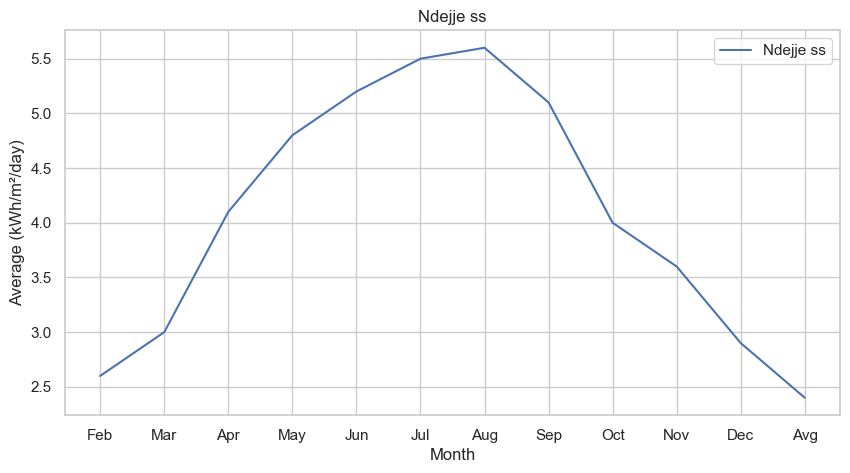

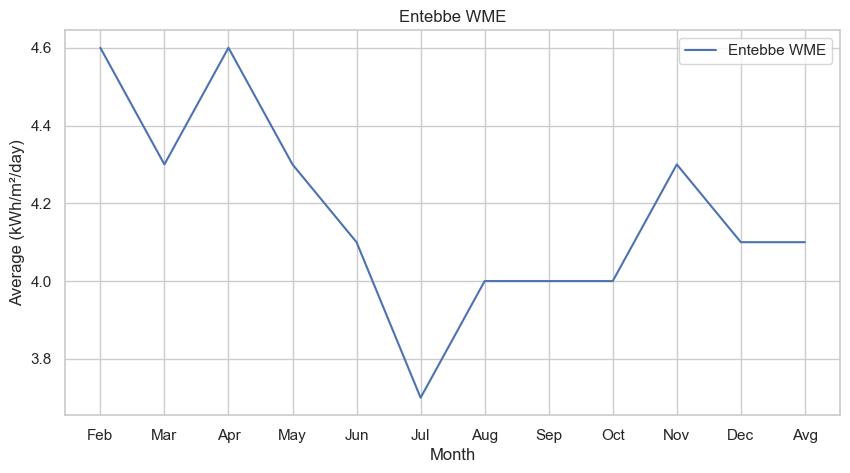

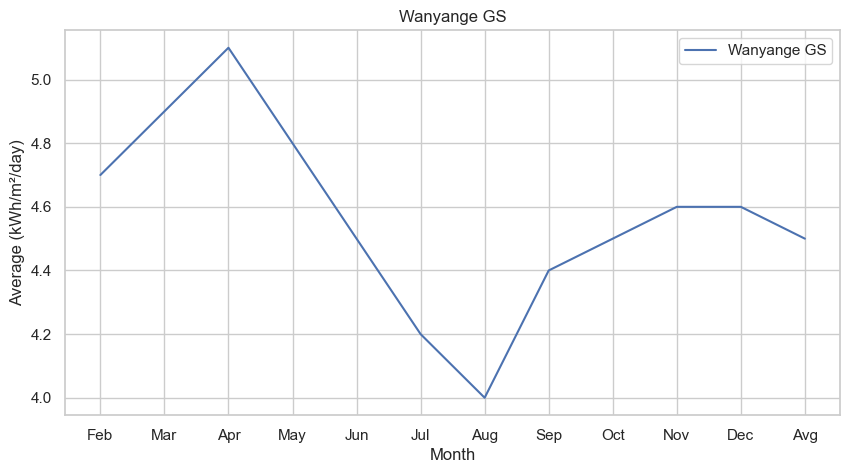

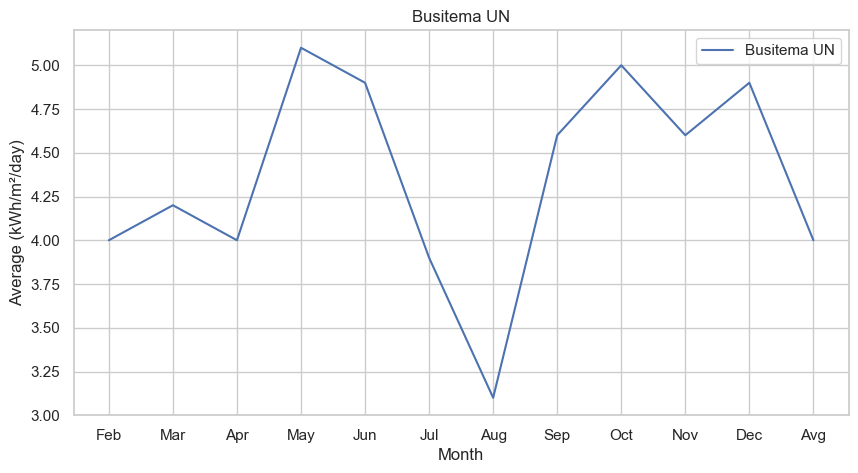

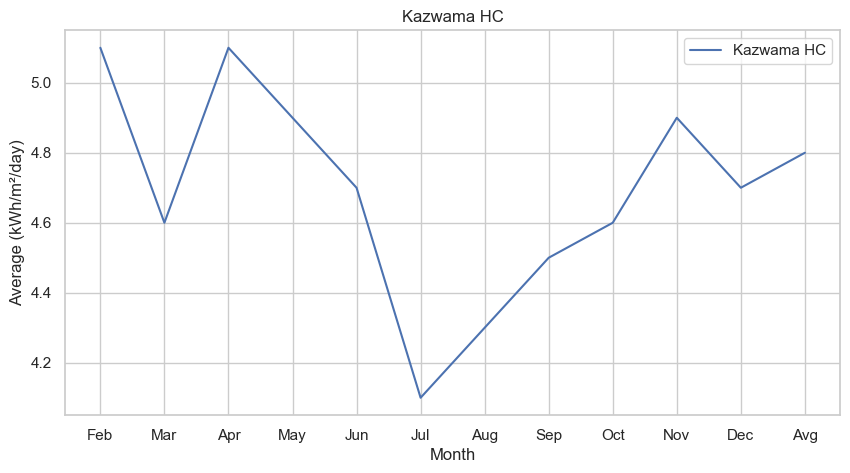

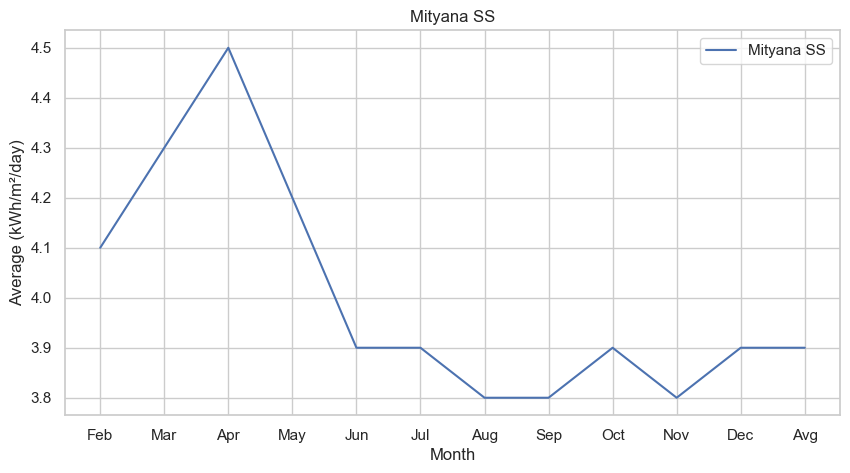

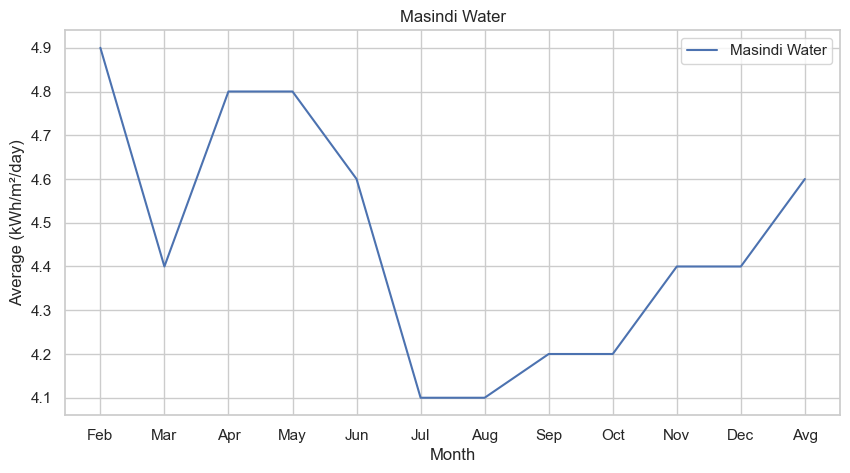

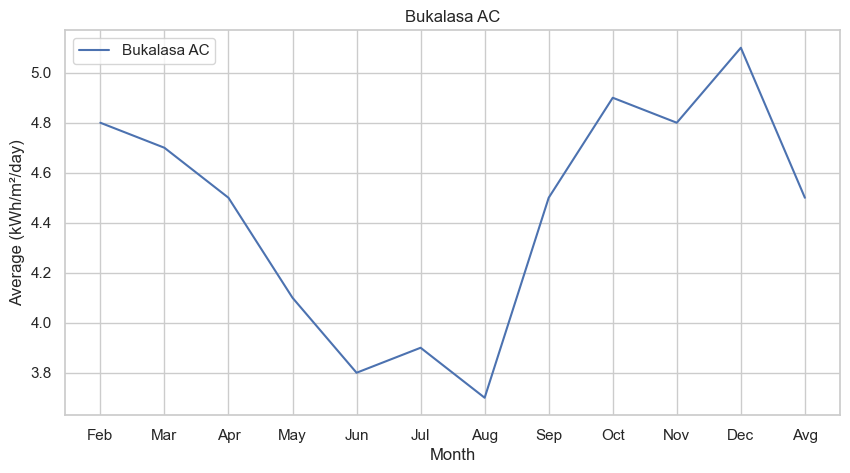

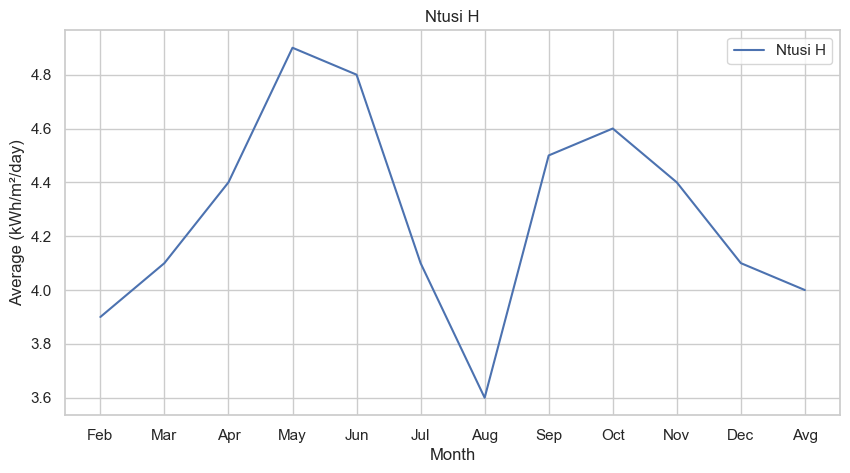

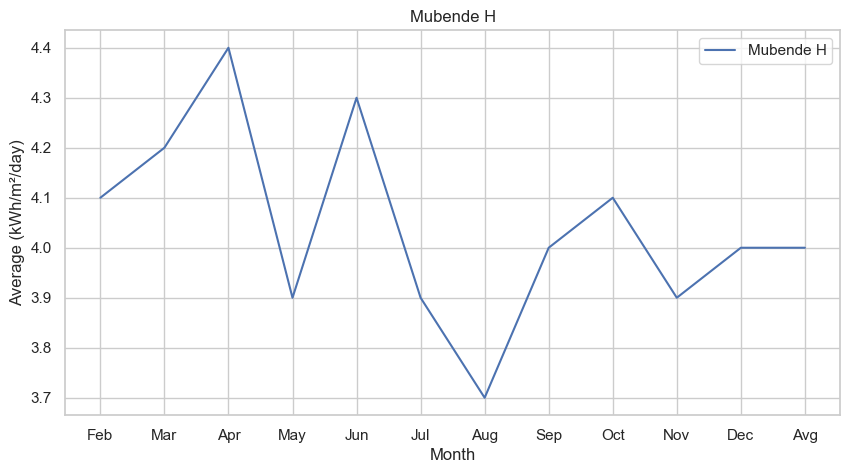

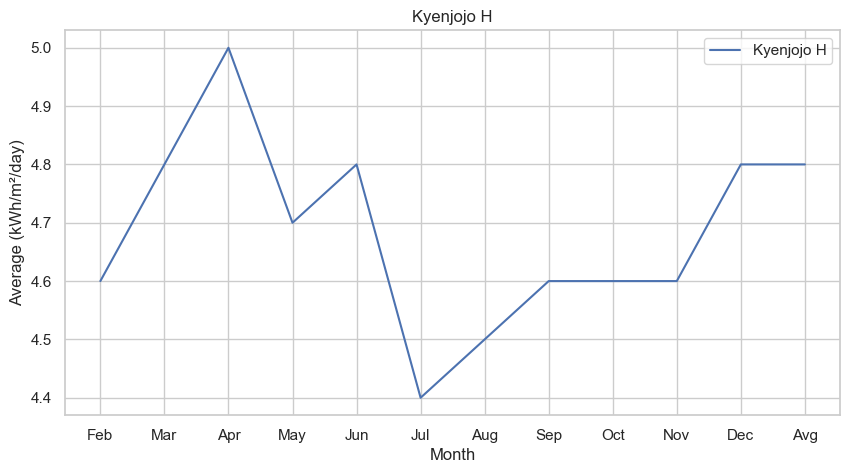

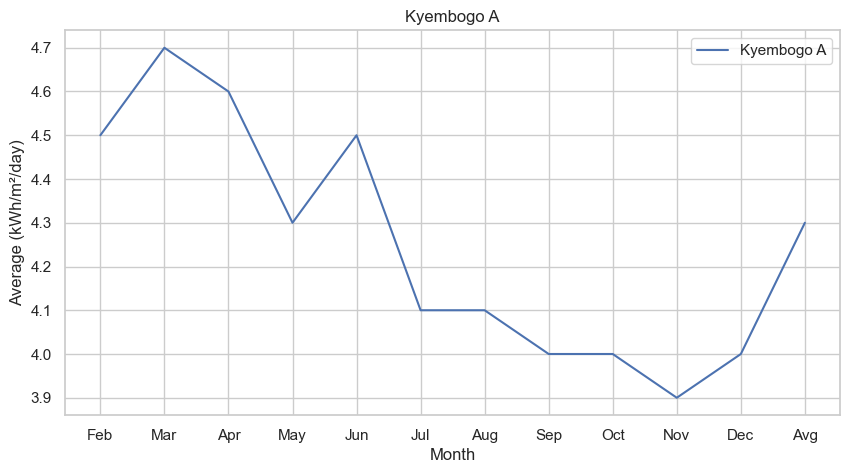

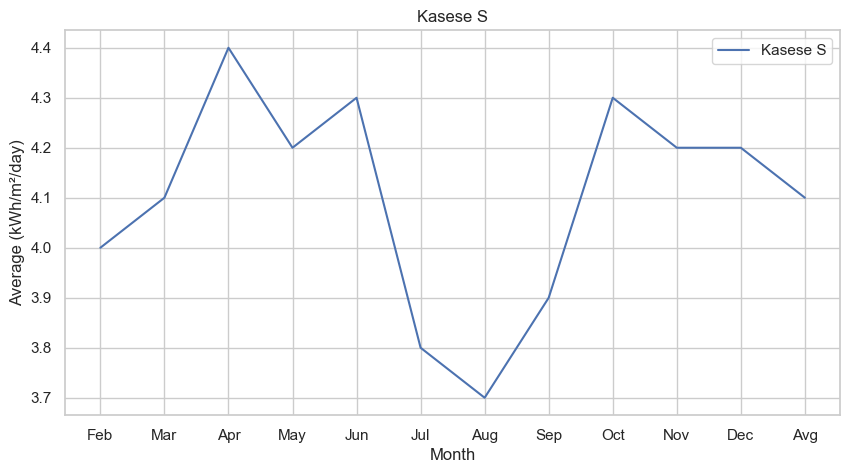

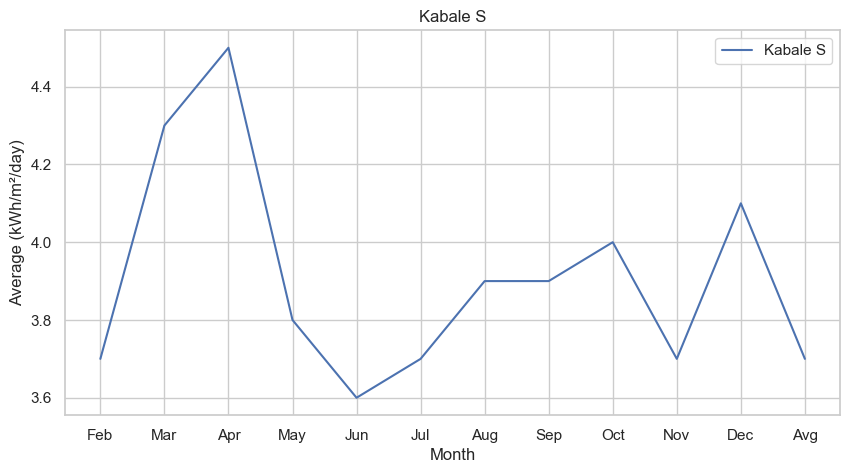

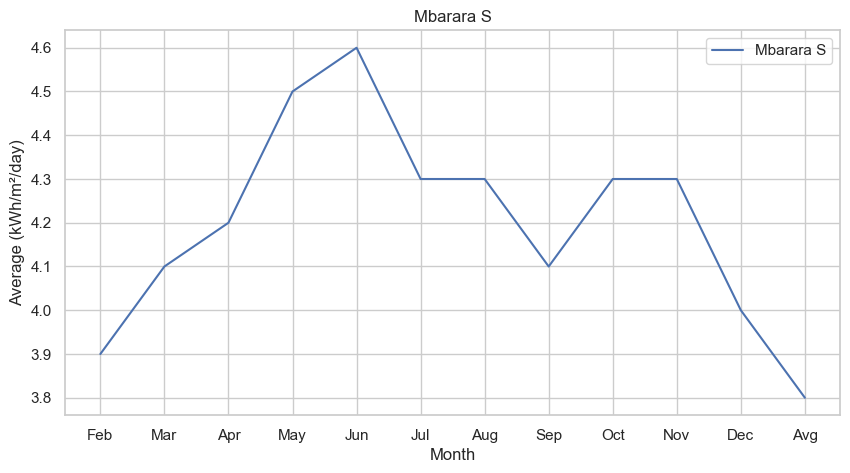

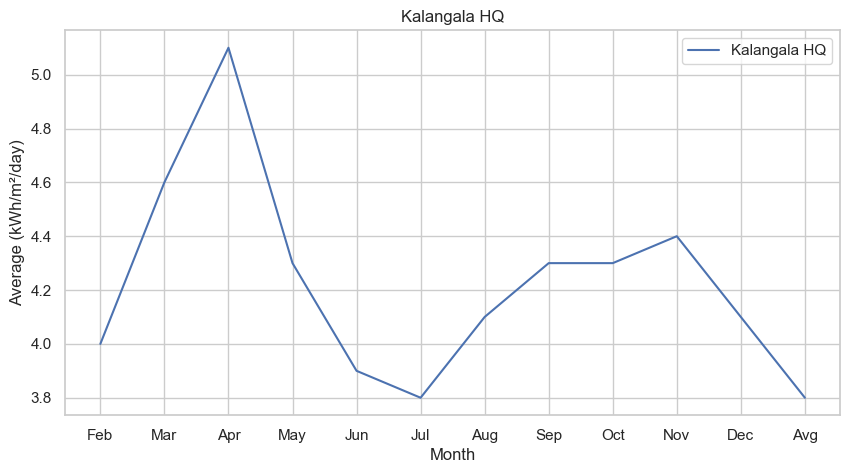

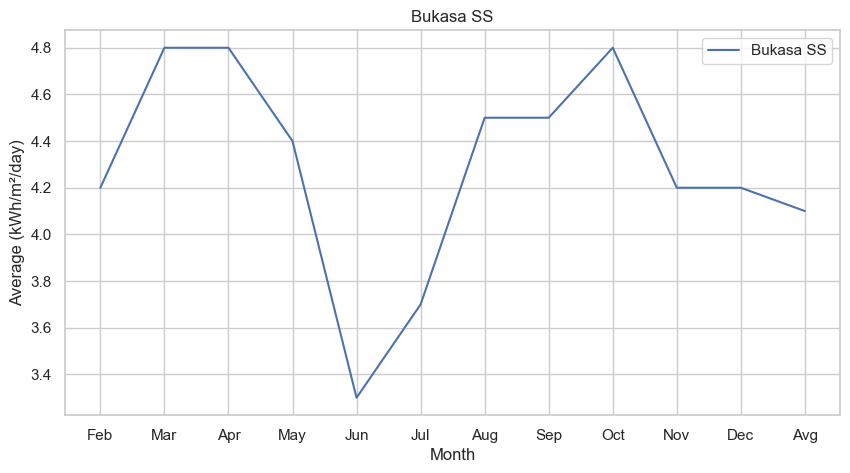

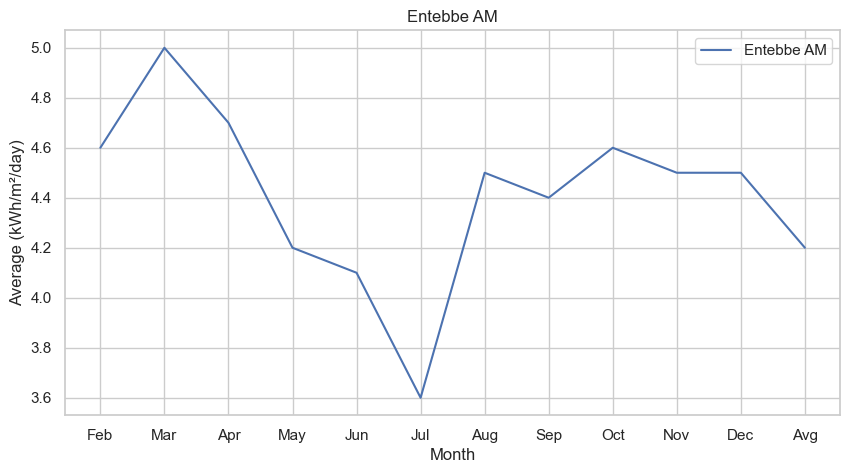

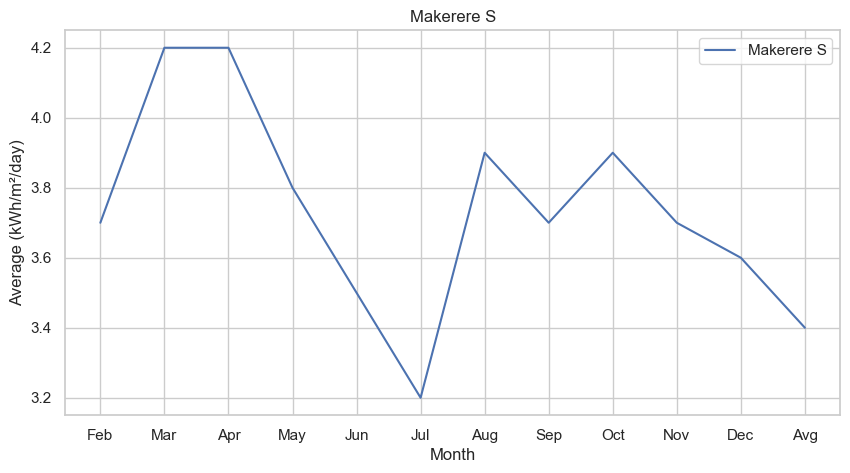

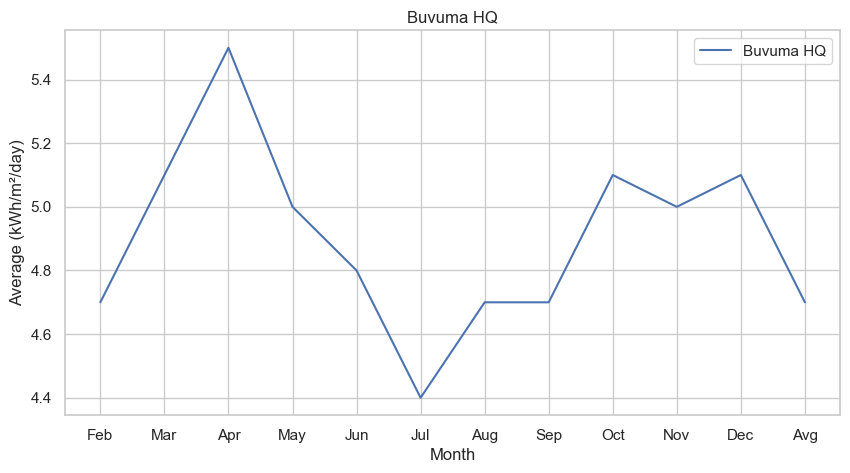

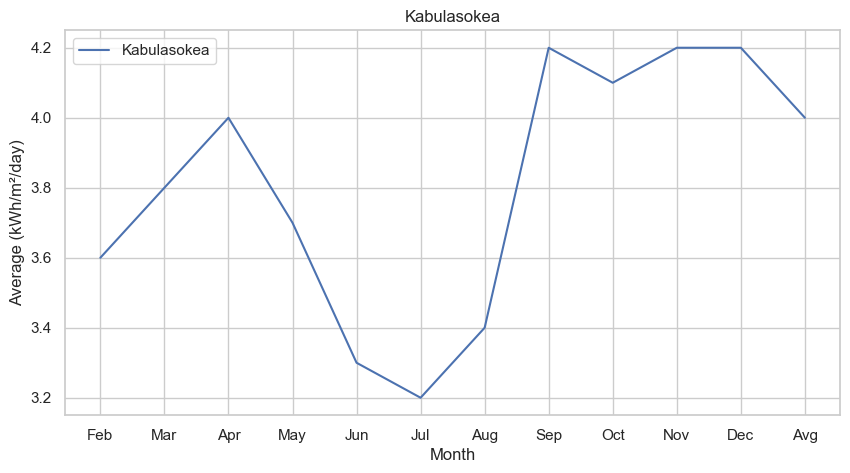

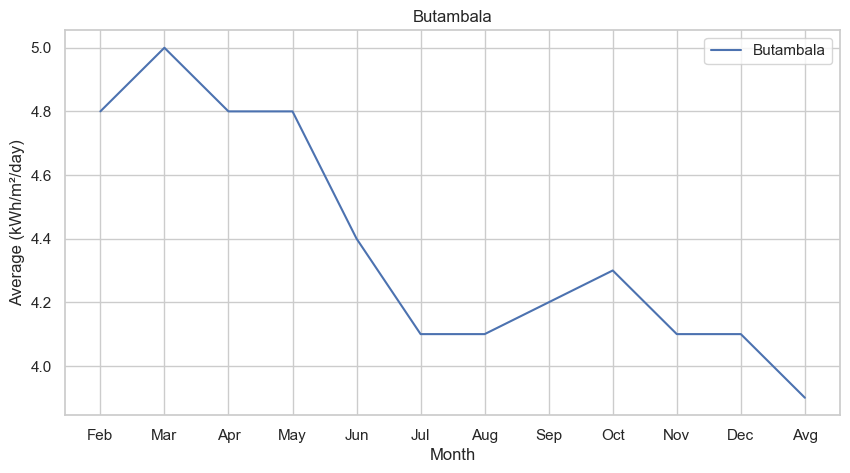

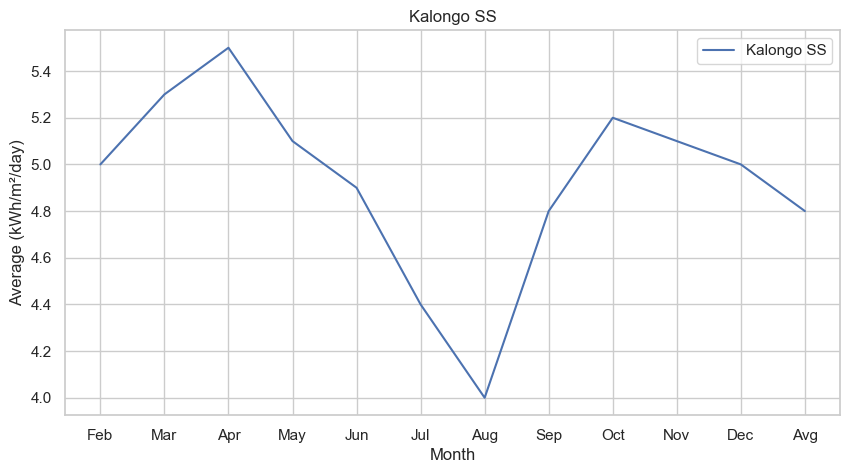

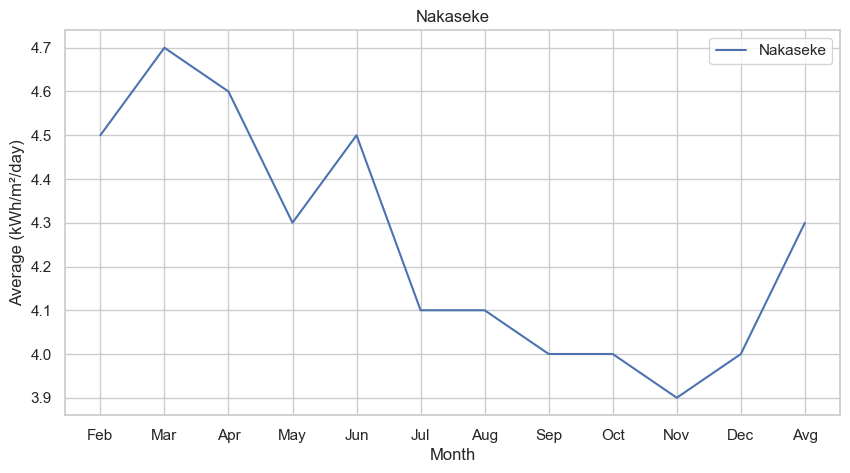

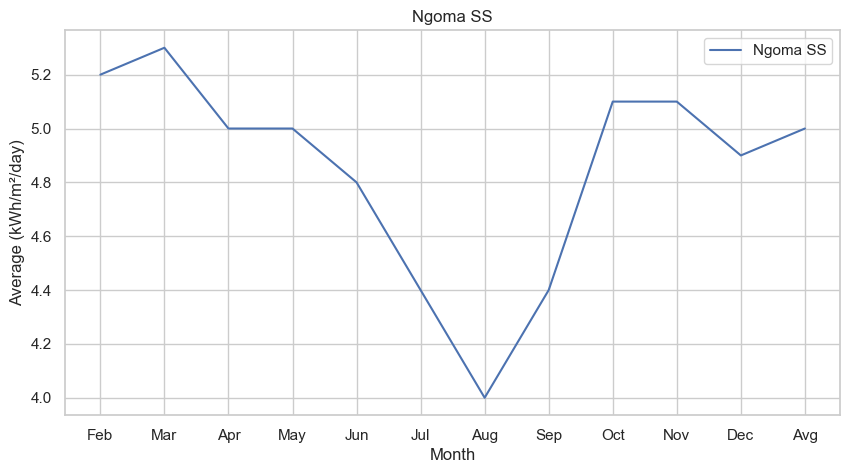

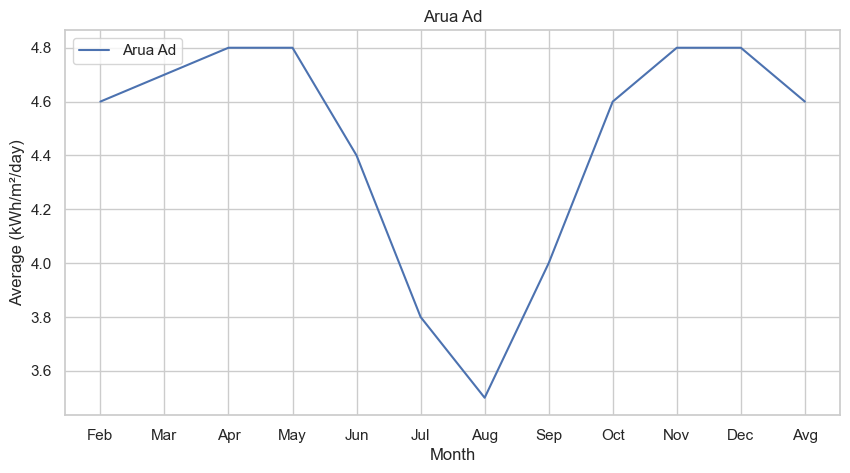

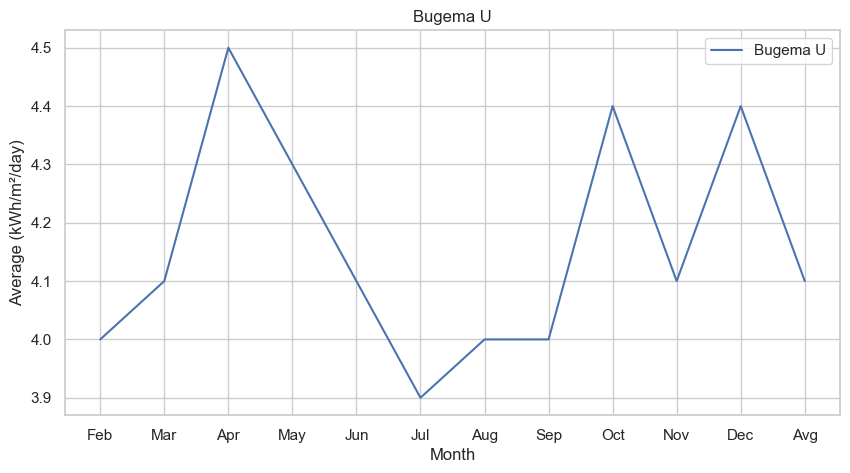

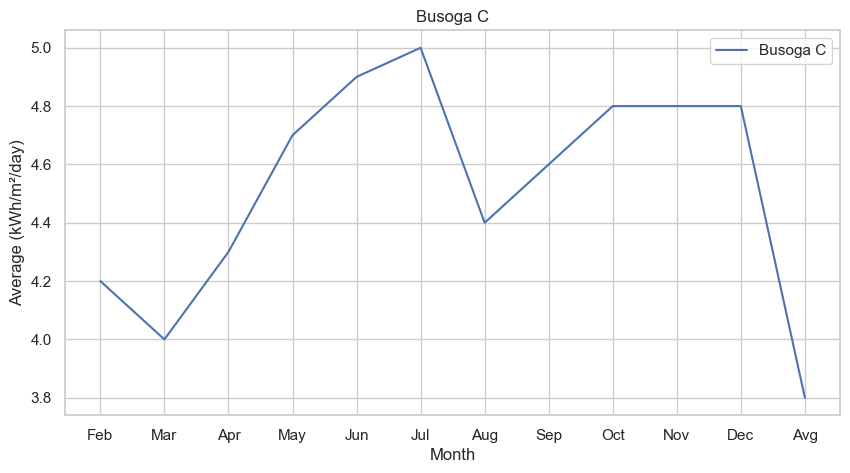

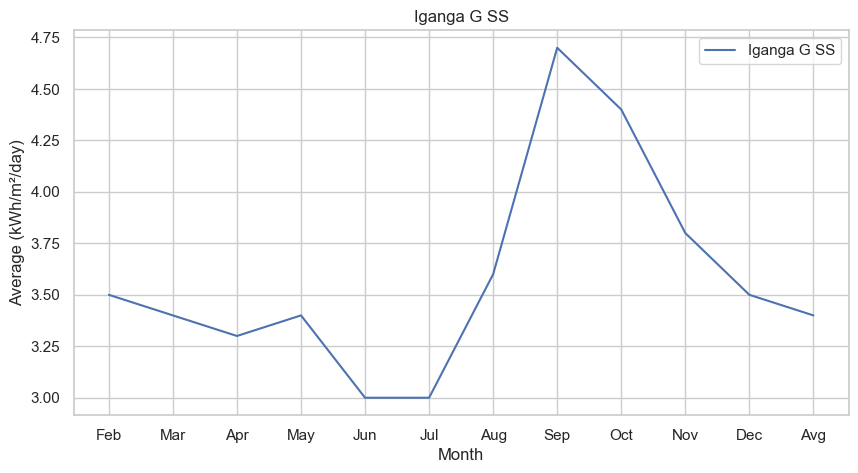

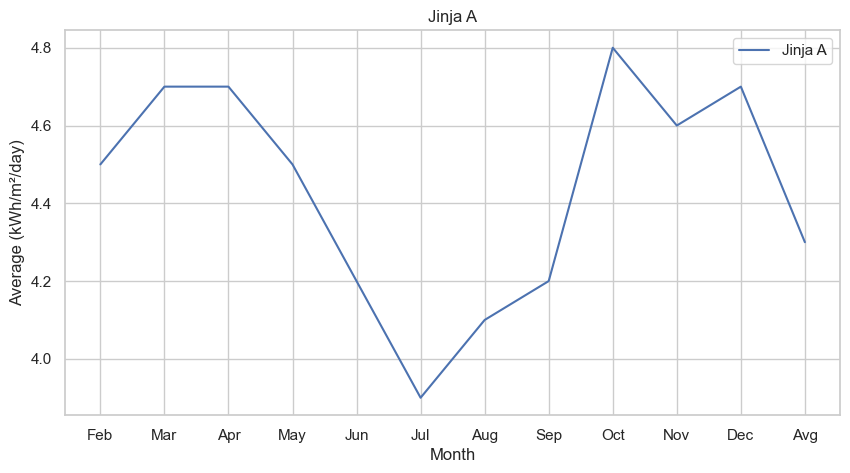

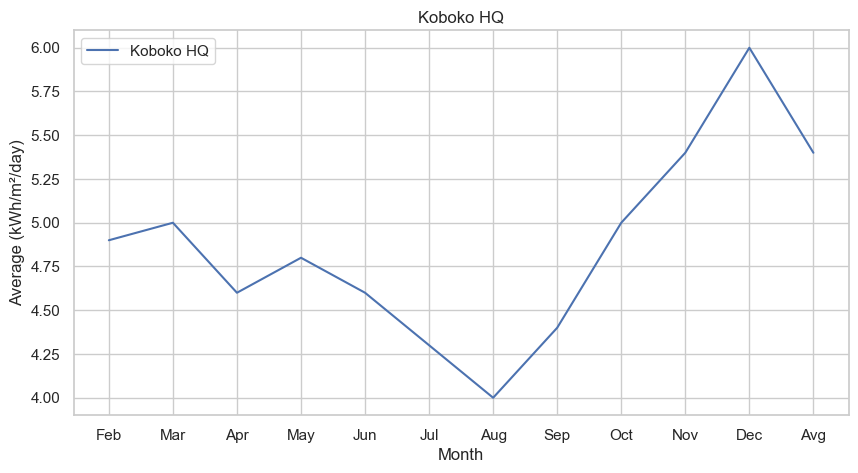

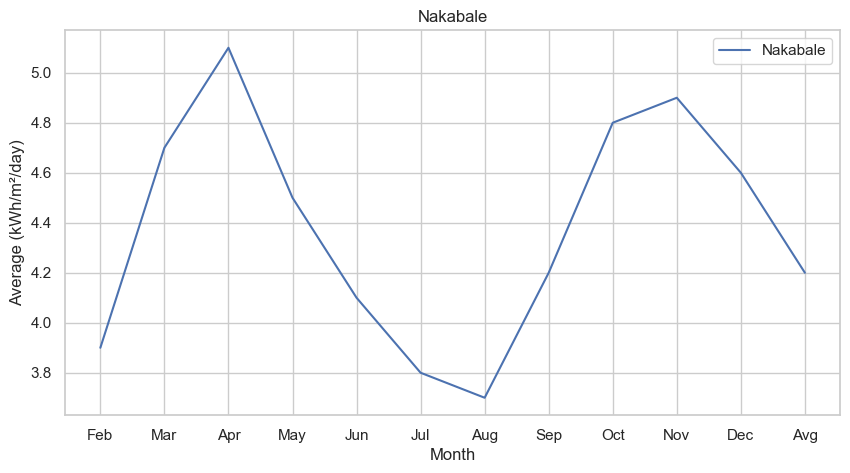

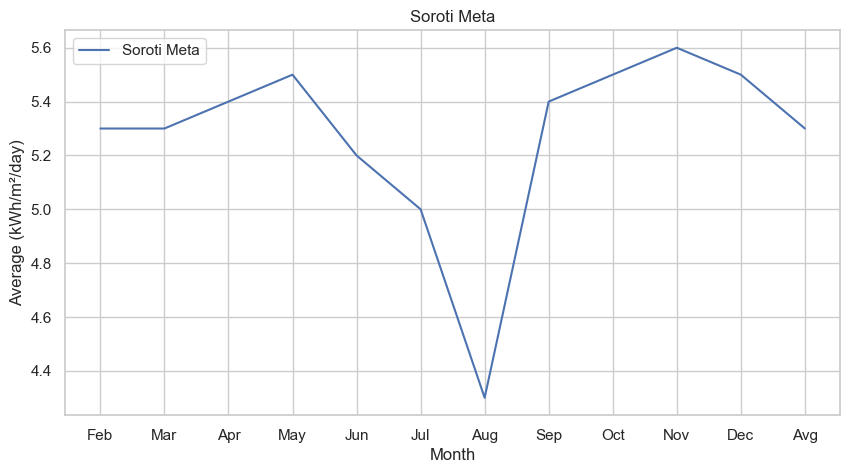

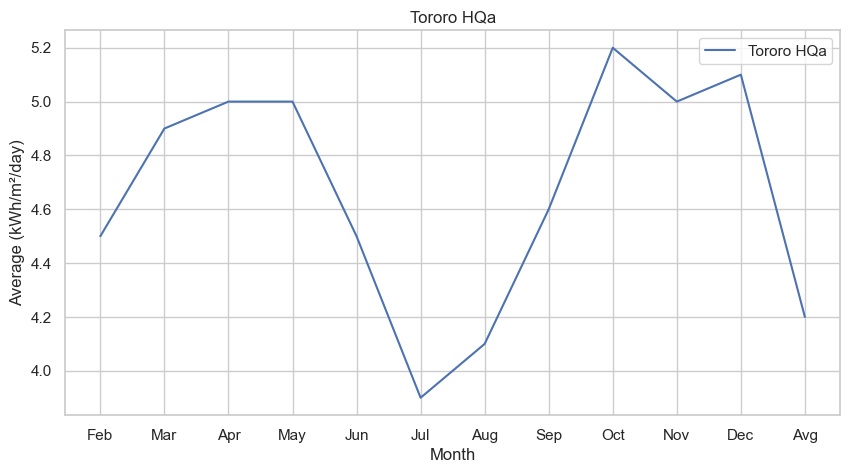

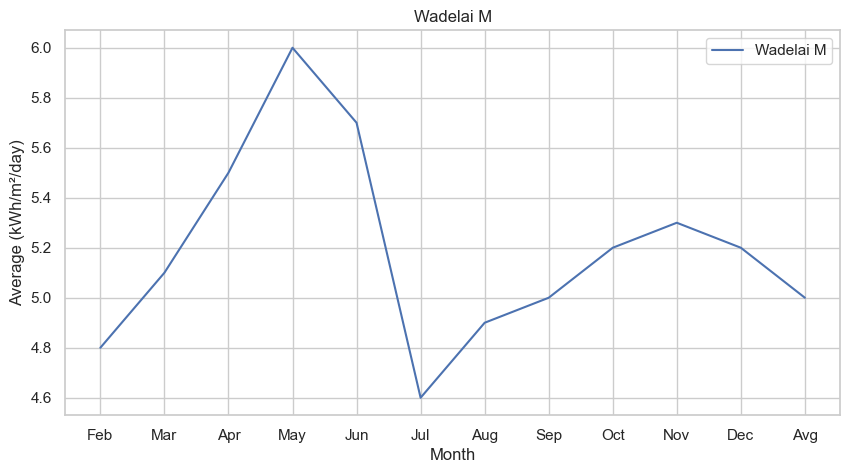

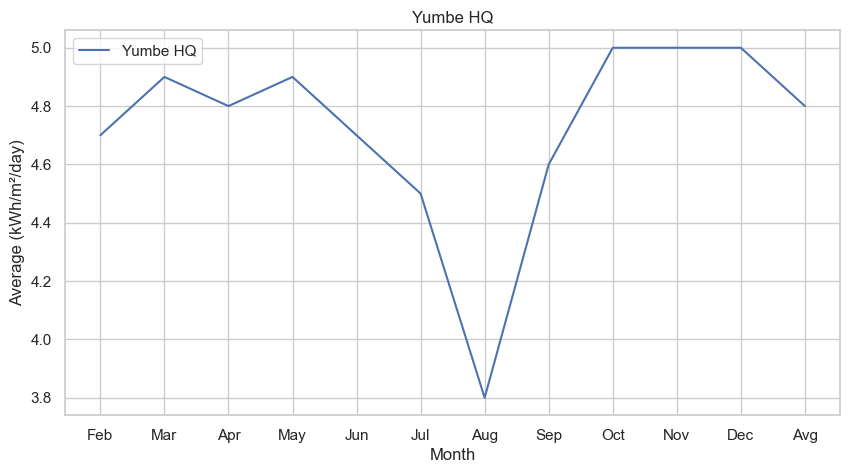

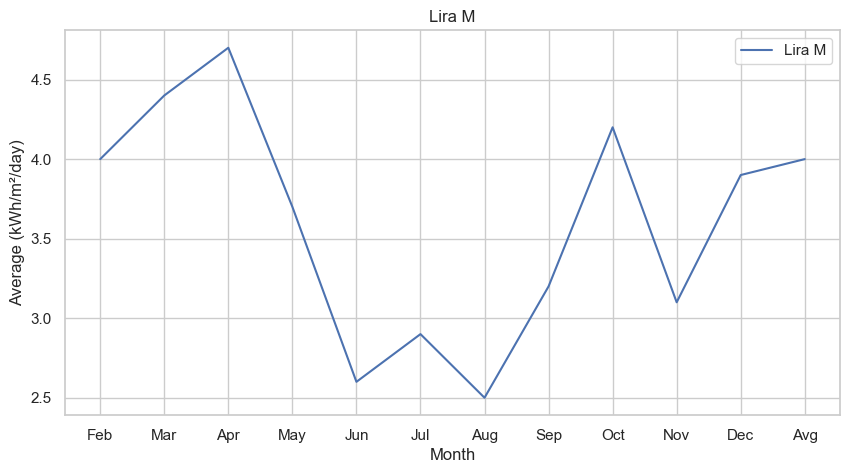

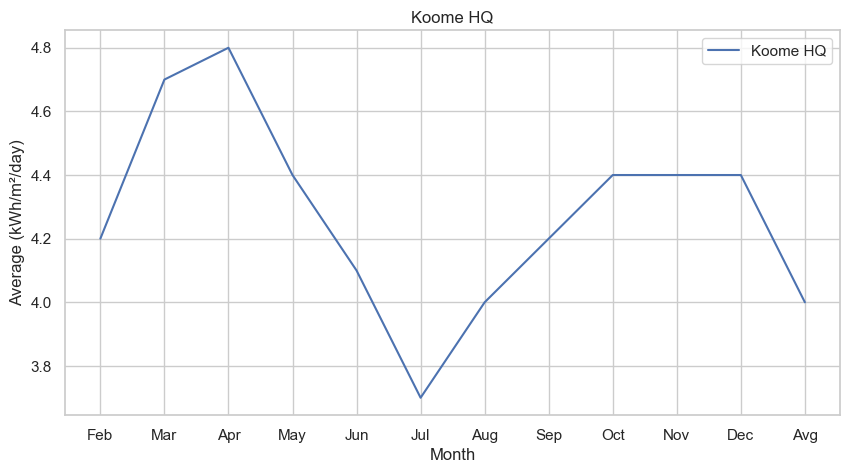

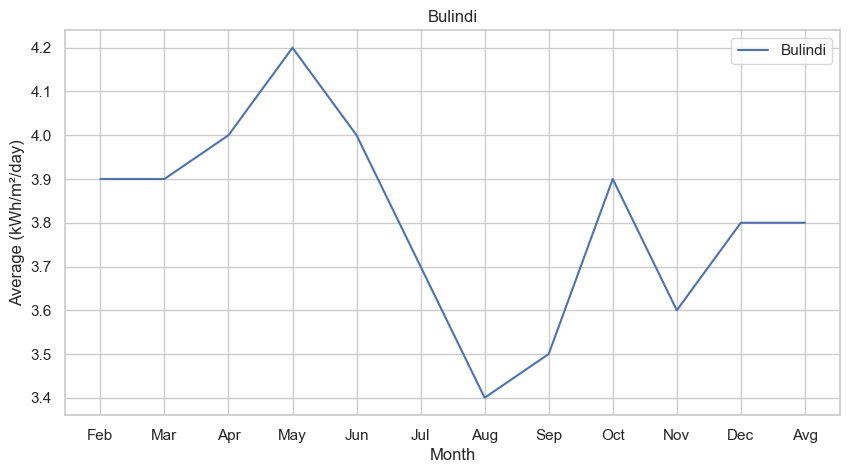

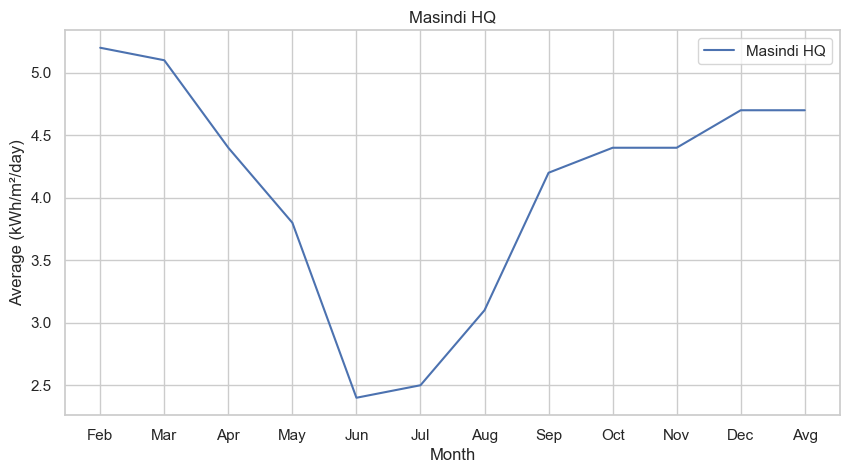

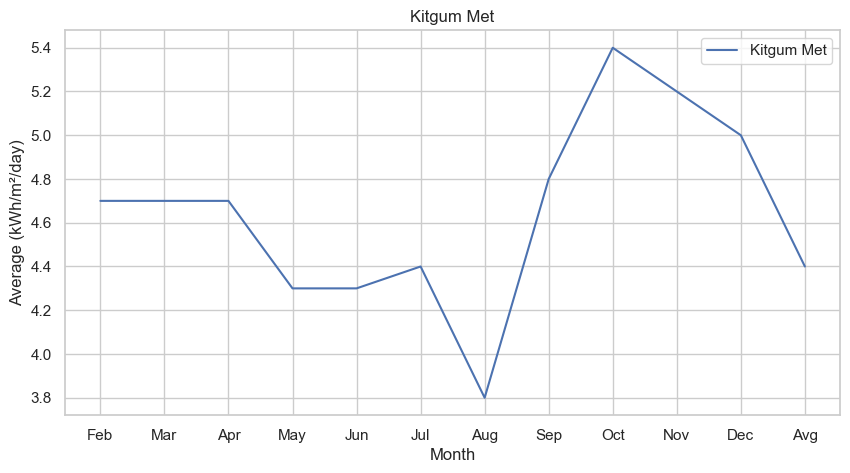

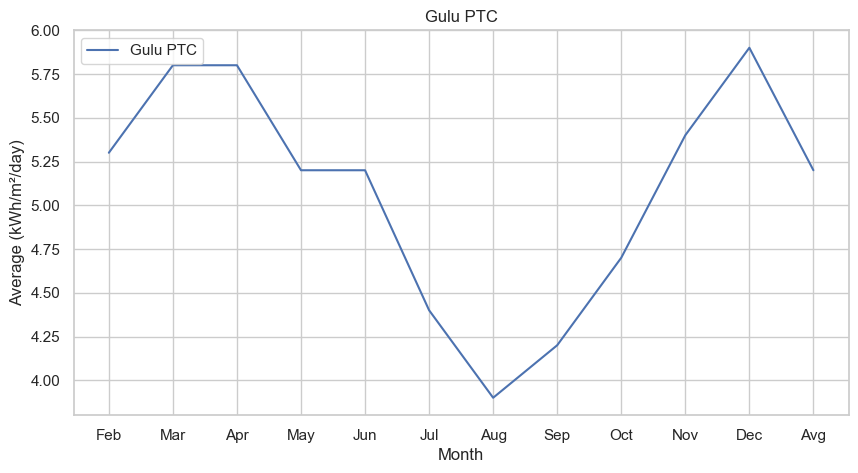

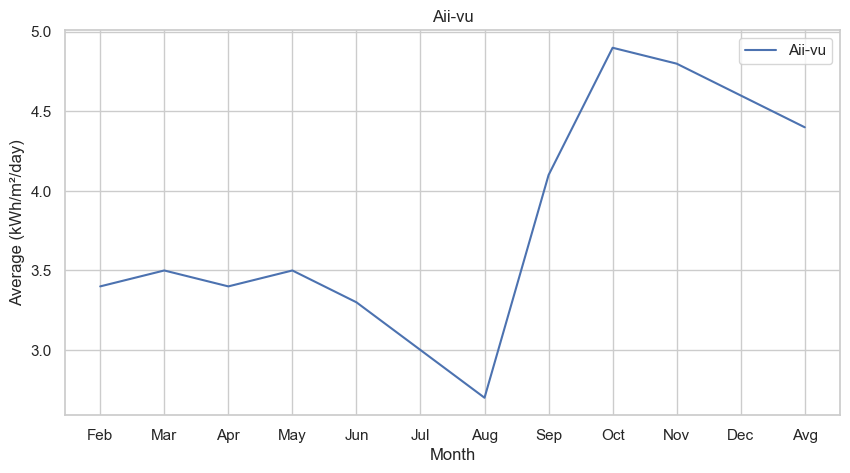

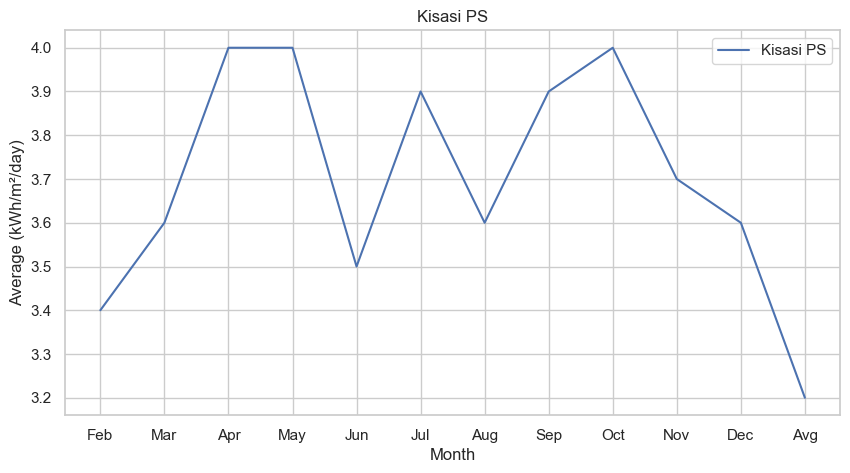

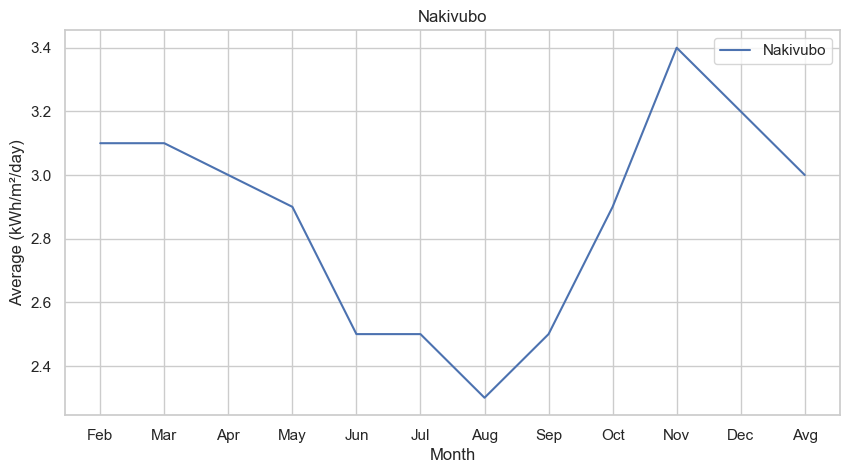

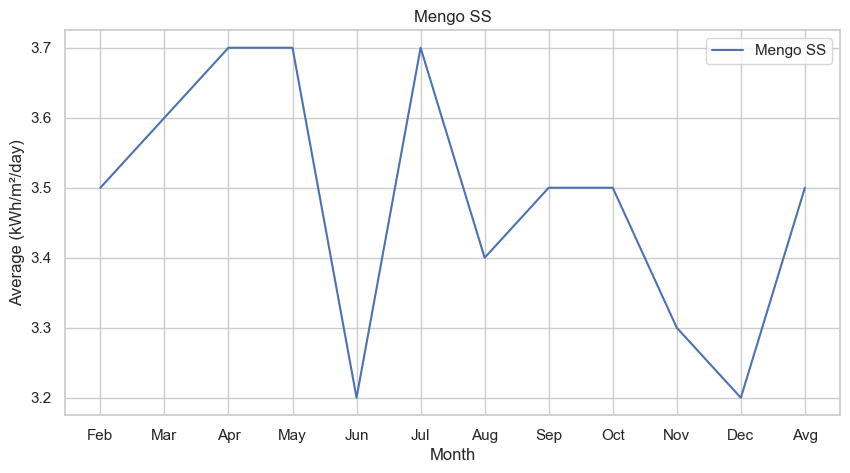

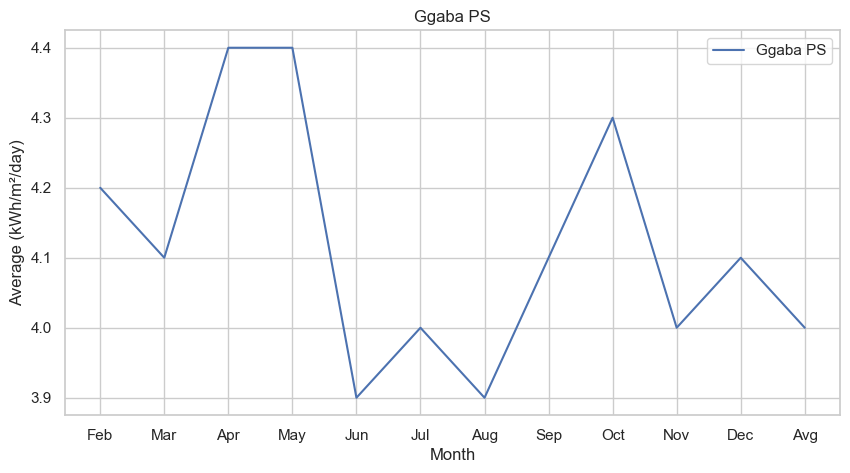

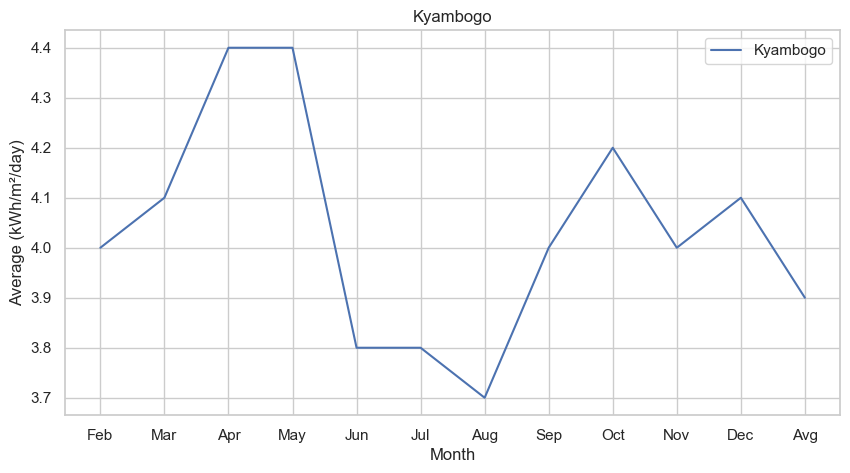

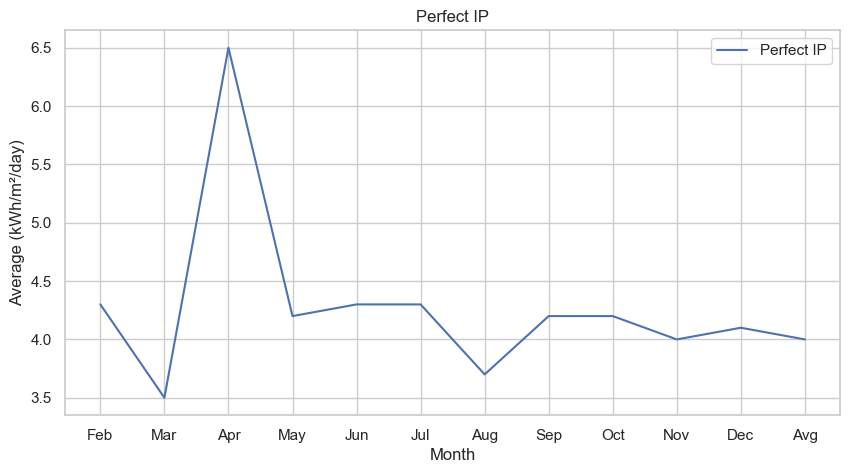

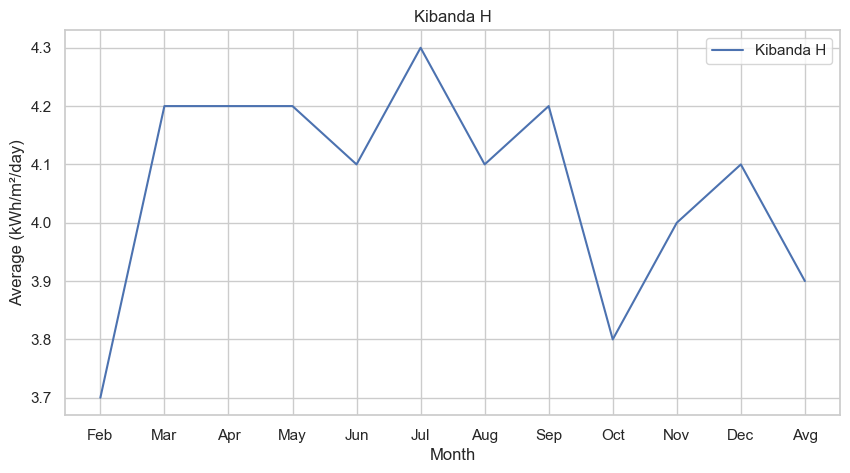

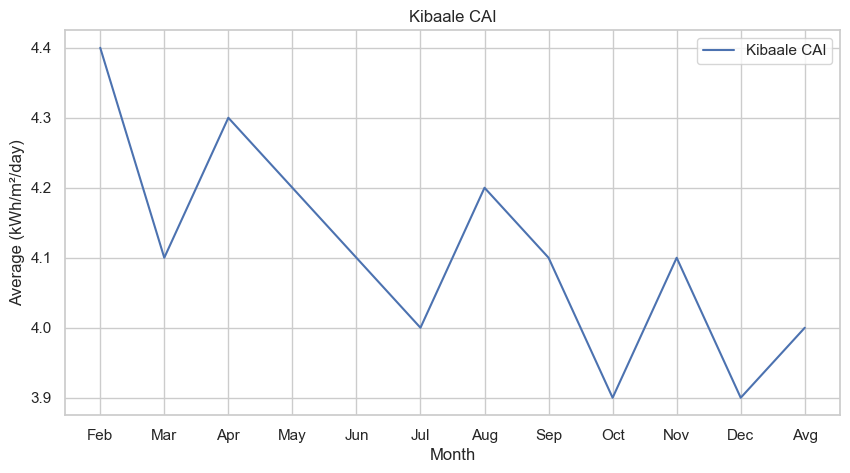

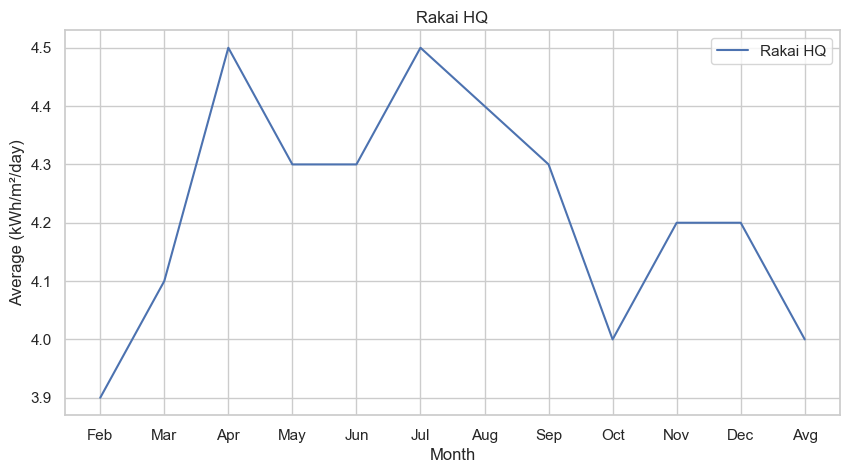

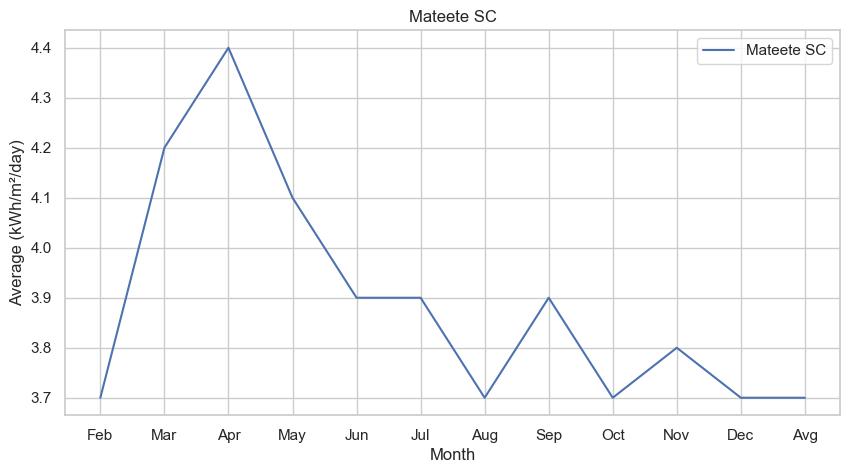

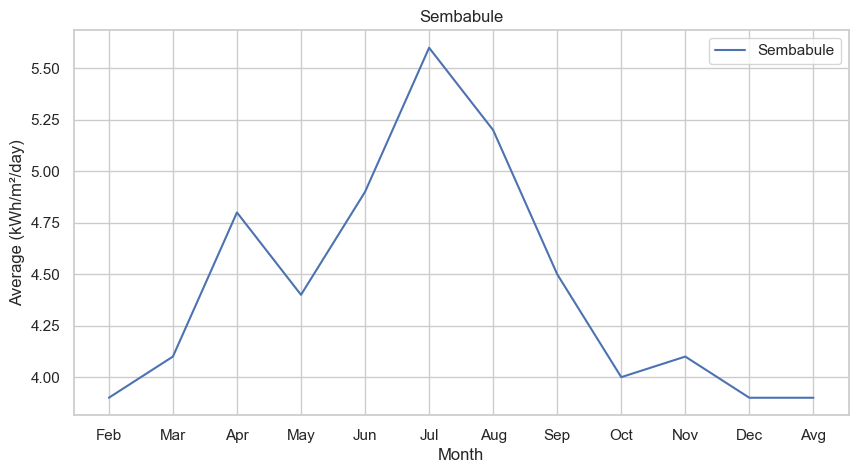

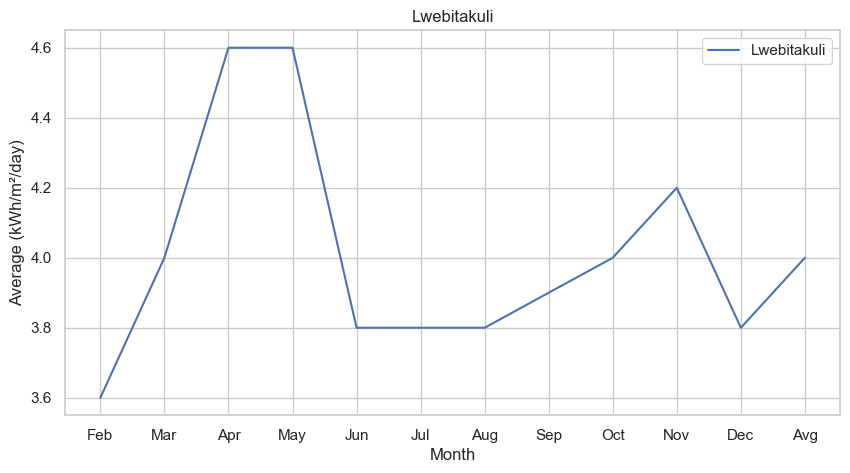

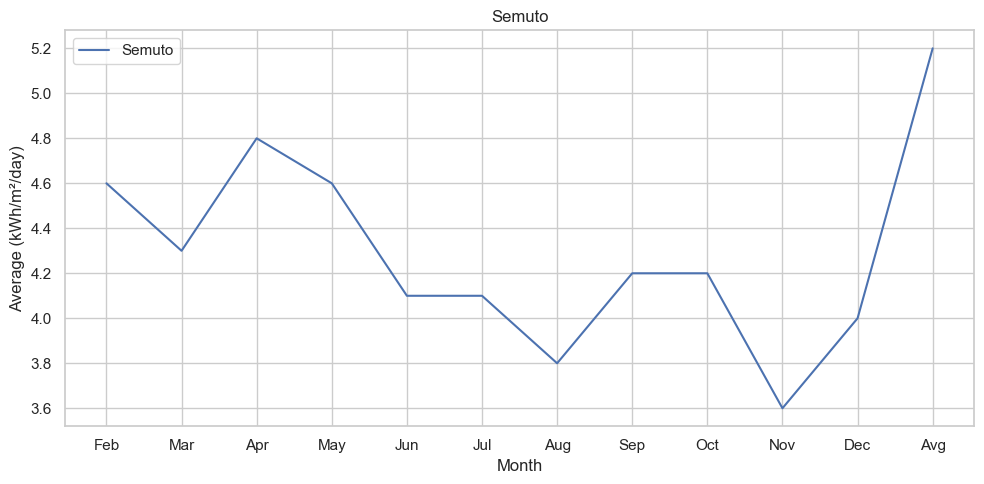

In [12]:
# plot each location on a separate plot 
# with the month on the x-axis and the average on the y-axis
import matplotlib.pyplot as plt
import seaborn as sns


for location in df_parsed.index:
		fig, axes = plt.subplots(figsize=(10, 5))
		axes.plot(df_parsed.columns[4:], df_parsed.loc[location, "Jan":"Dec"], label=location)
		axes.set_title(location)
		axes.set_xlabel("Month")
		axes.set_ylabel("Average (kWh/m²/day)")
		axes.legend()
plt.tight_layout()		
plt.show()

In [ ]:
def extract_location_metadata(df):
	"""
	Extracts metadata (latitude, longitude, altitude) from the DataFrame.

	Args:
		df (pd.DataFrame): DataFrame containing solar data with locations as index.

	Returns:
		dict: Dictionary with location names as keys and metadata as values.
	"""
	metadata = {}
	locations = df.index.tolist()
	for location in locations:
		start_date = 2015
		end_date = 2022
		metadata[location] = {
			'latitude': df.loc[location, 'Latitude'],
			'longitude': df.loc[location, 'Longitude'],
			'altitude': df.loc[location, 'Altitude'],
			'start_date': start_date,
			'end_date': end_date
		}
	return metadata

location_metadata = extract_location_metadata(df_parsed)
print("\n--- Location Metadata ---")
print(location_metadata)

KeyError: 'latitude'